In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [3]:
# ======== DIRECTORY MANAGEMENT =========


# Adding project root to the system path list
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Access data directory
data_dir = project_root / "data"

# train_data directory
train_data_dir = data_dir / "train.csv"

train_data_dir

WindowsPath('c:/Users/user/Desktop/housing_prediction_DF_proj_1/data/train.csv')

In [4]:
# Import function from modules
from scripts.preprocess import transform_data

In [5]:
# ======= LOAD DATAFRAME ======
df = pd.read_csv(train_data_dir)

df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [6]:
# ====== TRANSFORM DATA =====
df = transform_data(df)

df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,READY_TO_MOVE,RESALE,CITY,TARGET(PRICE_IN_LACS)_LOG,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQUARE_FT_CLIPPED
0,Owner,0,0,BHK,1,1,Bangalore,4.025352,2,77.597960,12.969910,1300.236407
1,Dealer,0,0,BHK,1,1,Mysore,3.951244,2,76.644605,12.274538,1275.000000
2,Owner,0,0,BHK,1,1,Bangalore,3.784190,2,77.632191,12.778033,933.159722
3,Owner,0,1,BHK,1,1,Ghaziabad,4.151040,2,77.344500,28.642300,929.921143
4,Dealer,1,0,BHK,0,1,Kolkata,4.119037,2,83.874699,22.592200,999.009247


In [7]:
# List of numeric column names

list(df.select_dtypes(include='number').columns)

['UNDER_CONSTRUCTION',
 'RERA',
 'READY_TO_MOVE',
 'RESALE',
 'TARGET(PRICE_IN_LACS)_LOG',
 'BHK_NO._CAPPED',
 'LATITUDE_CLIPPED',
 'LONGITUDE_CLIPPED',
 'SQUARE_FT_CLIPPED']

In [8]:
# List of Categorical column names

df.select_dtypes(include="object").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   POSTED_BY  29451 non-null  object
 1   BHK_OR_RK  29451 non-null  object
 2   CITY       29451 non-null  object
dtypes: object(3)
memory usage: 690.4+ KB


## FEATURES ENGINEERING 

- drop multicollinear features
- create new effective features


In [9]:
# ====== DROP MULTICOLLINEAR FEATURE ====

df.drop(columns='READY_TO_MOVE', inplace=True)

In [10]:
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,RESALE,CITY,TARGET(PRICE_IN_LACS)_LOG,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQUARE_FT_CLIPPED
0,Owner,0,0,BHK,1,Bangalore,4.025352,2,77.597960,12.969910,1300.236407
1,Dealer,0,0,BHK,1,Mysore,3.951244,2,76.644605,12.274538,1275.000000
2,Owner,0,0,BHK,1,Bangalore,3.784190,2,77.632191,12.778033,933.159722
3,Owner,0,1,BHK,1,Ghaziabad,4.151040,2,77.344500,28.642300,929.921143
4,Dealer,1,0,BHK,1,Kolkata,4.119037,2,83.874699,22.592200,999.009247


<Axes: ylabel='Frequency'>

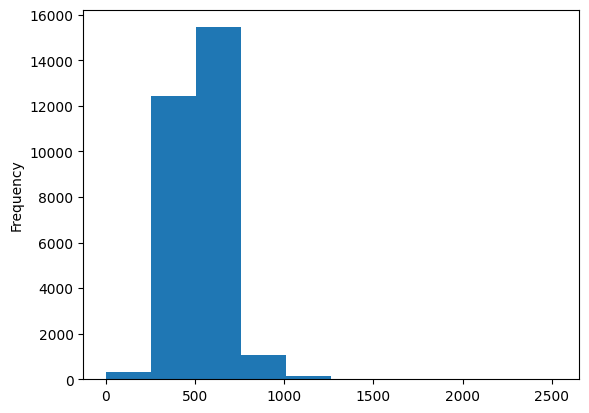

In [11]:
# ===== CREATE "SQRFT_PER_BHK_NO" FEATURE =======

# create_new_features
df["SQRFT_PER_BHK_NO"] = df["SQUARE_FT_CLIPPED"] / df["BHK_NO._CAPPED"]

df["SQRFT_PER_BHK_NO"].plot(kind="hist")

<Axes: >

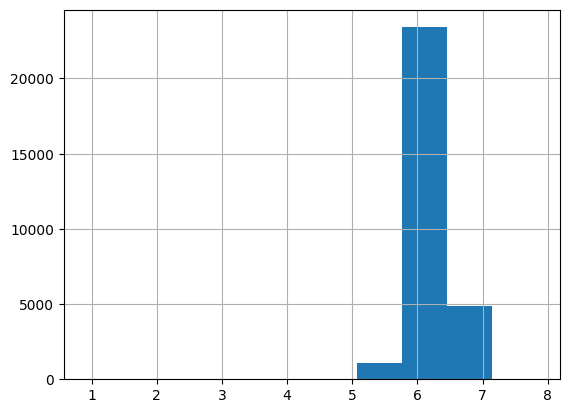

In [12]:
# log transform the new feature
df["SQRFT_PER_BHK_LOG"] = np.log1p(df["SQRFT_PER_BHK_NO"])

#  drop non-log feature
df.drop(columns="SQRFT_PER_BHK_NO", inplace=True)

df["SQRFT_PER_BHK_LOG"].hist()

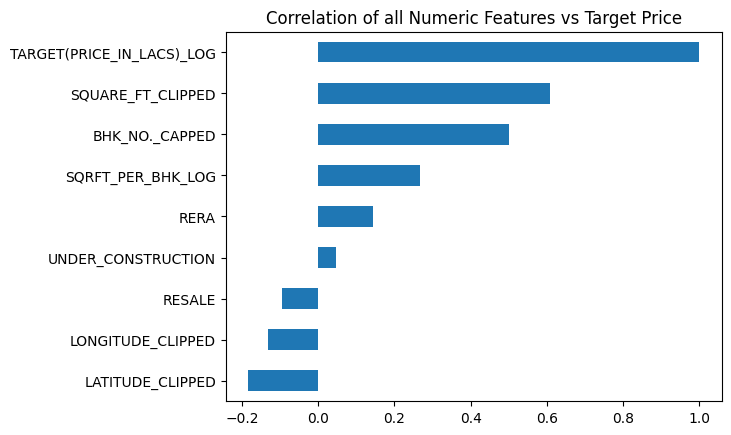

In [13]:
# check correlation again
(
    df.select_dtypes(include="number")
    .corr()["TARGET(PRICE_IN_LACS)_LOG"]
    .sort_values()
    .plot(kind="barh")
)
plt.title("Correlation of all Numeric Features vs Target Price")
plt.show()

<Axes: >

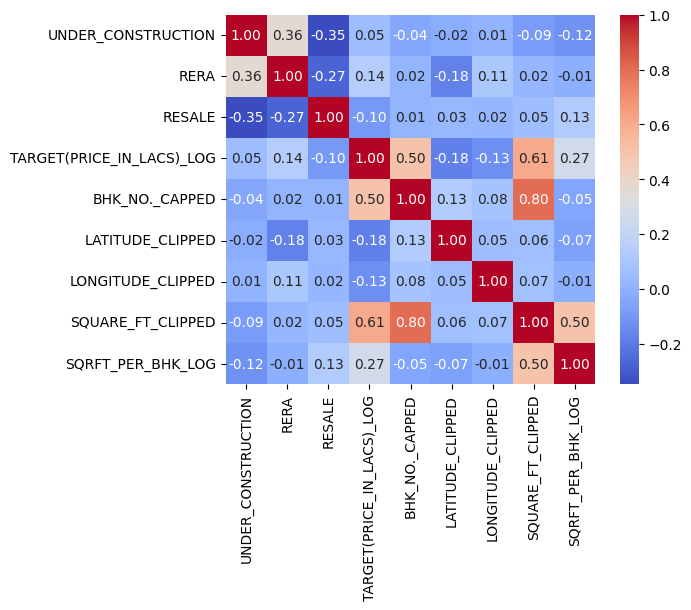

In [14]:
# Check HeatMap Again
corr_mat =  df.select_dtypes(include="number").corr()

sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap= "coolwarm",
    square=True,
    cbar=True,

)

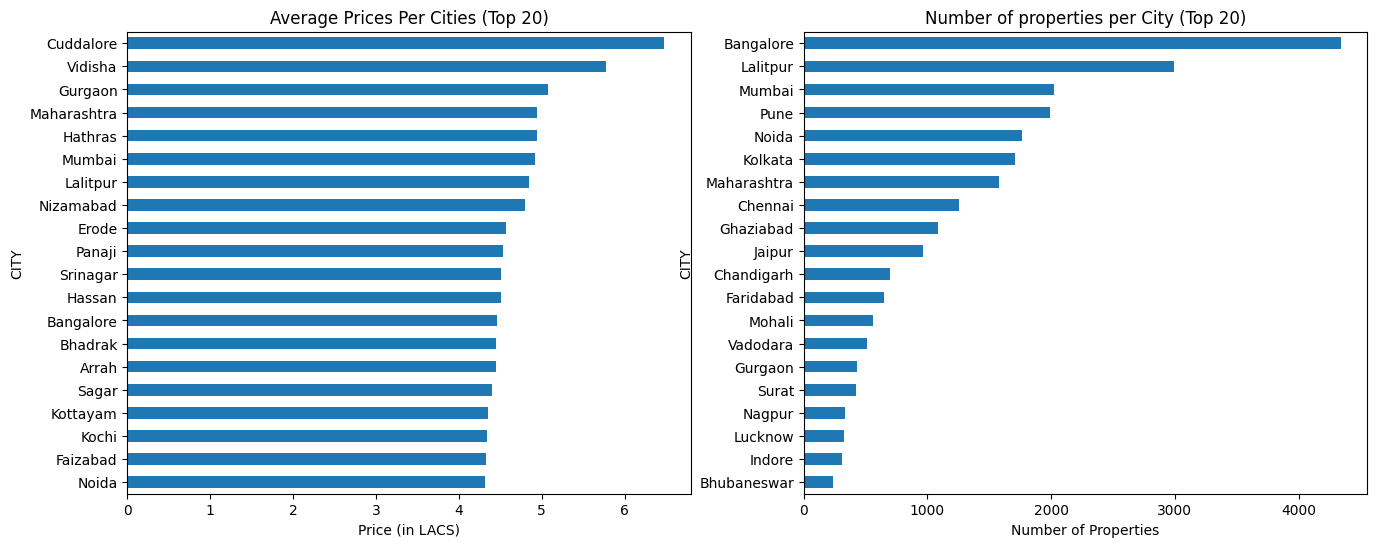

In [15]:
# ======= CITY FEATURE HANDLING =======

# mean price per city
city_means = df.groupby("CITY")["TARGET(PRICE_IN_LACS)_LOG"].mean()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

city_means.sort_values(ascending=True).tail(20).plot(kind="barh", ax=ax[0])
ax[0].set_title("Average Prices Per Cities (Top 20)")
ax[0].set_xlabel("Price (in LACS)")

df["CITY"].value_counts().sort_values().tail(20).plot(kind="barh", ax=ax[1])
ax[1].set_title("Number of properties per City (Top 20)")
ax[1].set_xlabel ("Number of Properties")

plt.show()

In [16]:
city_means

CITY
Agartala        3.988984
Agra            3.585627
Ahmednagar      3.370684
Ajmer           3.486641
Akola           3.446912
                  ...   
Vizianagaram    3.272413
Warangal        3.881935
Wardha          3.179455
Washim          3.295837
Yavatmal        3.101268
Name: TARGET(PRICE_IN_LACS)_LOG, Length: 256, dtype: float64

In [20]:
# Create numerical features from City
df["AVG_PRICE_PER_CITY"] = df["CITY"].map(city_means)

# Drop CITY column
df.drop(columns="CITY", inplace=True)

df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,RESALE,TARGET(PRICE_IN_LACS)_LOG,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQUARE_FT_CLIPPED,SQRFT_PER_BHK_LOG,AVG_PRICE_PER_CITY
0,Owner,0,0,BHK,1,4.025352,2,77.597960,12.969910,1300.236407,6.478691,4.456091
1,Dealer,0,0,BHK,1,3.951244,2,76.644605,12.274538,1275.000000,6.459122,4.097937
2,Owner,0,0,BHK,1,3.784190,2,77.632191,12.778033,933.159722,6.147570,4.456091
3,Owner,0,1,BHK,1,4.151040,2,77.344500,28.642300,929.921143,6.144101,3.840646
4,Dealer,1,0,BHK,1,4.119037,2,83.874699,22.592200,999.009247,6.215617,4.003438


In [ ]:
# Perform OneHotEncoder on the remaining categorical features

categorical_cols = df.select_dtypes(include="object").columns.tolist()

# instantiate OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

# fit and transform the categorical columns
ohe.fit(df[categorical_cols])
ohe_array = ohe.transform(df[categorical_cols])

# create DataFrame from the ohe_array
features_name = ohe.get_feature_names_out(categorical_cols)
df_ohe = pd.DataFrame(ohe_array, columns=features_name, index=df.index)

# concatenate the new one-hot-encoded columns to the original DataFrame
df = pd.concat([df, df_ohe], axis=1)

# drop the original categorical columns
df.drop(columns=categorical_cols, inplace=True)

df.head()

,UNDER_CONSTRUCTION,RERA,RESALE,TARGET(PRICE_IN_LACS)_LOG,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQUARE_FT_CLIPPED,SQRFT_PER_BHK_LOG,AVG_PRICE_PER_CITY,POSTED_BY_Dealer,POSTED_BY_Owner,BHK_OR_RK_RK,POSTED_BY_Dealer,POSTED_BY_Owner,BHK_OR_RK_RK
0,0,0,1,4.025352,2,77.597960,12.969910,1300.236407,6.478691,4.456091,0.0,1.0,0.0,0.0,1.0,0.0
1,0,0,1,3.951244,2,76.644605,12.274538,1275.000000,6.459122,4.097937,1.0,0.0,0.0,1.0,0.0,0.0
2,0,0,1,3.784190,2,77.632191,12.778033,933.159722,6.147570,4.456091,0.0,1.0,0.0,0.0,1.0,0.0
3,0,1,1,4.151040,2,77.344500,28.642300,929.921143,6.144101,3.840646,0.0,1.0,0.0,0.0,1.0,0.0
4,1,0,1,4.119037,2,83.874699,22.592200,999.009247,6.215617,4.003438,1.0,0.0,0.0,1.0,0.0,0.0


Text(0.5, 0, 'Correlation Coefficient')

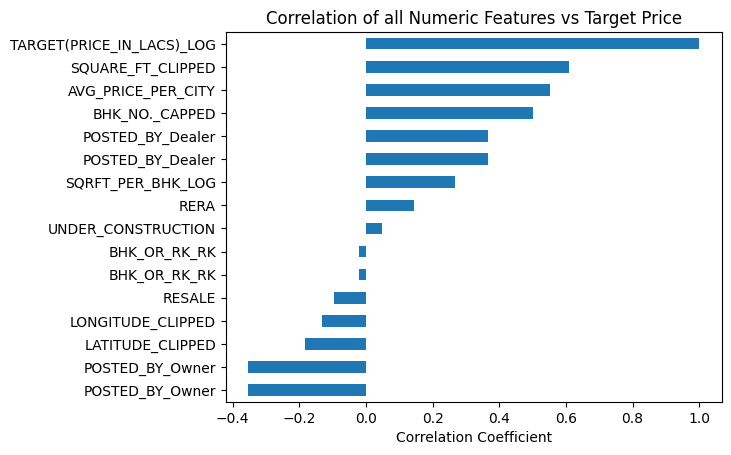

In [32]:
df.corr()["TARGET(PRICE_IN_LACS)_LOG"].sort_values(ascending=True).plot(kind="barh")
plt.title("Correlation of all Numeric Features vs Target Price")
plt.xlabel("Correlation Coefficient")